<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Feature_Scaling_in_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np

In [38]:
df=pd.read_csv('Social_Network_Ads.csv')

In [39]:
df


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [40]:
df.drop_duplicates().sum()

,0
User ID,6276615903
Gender,MaleMaleFemaleFemaleMaleMaleFemaleFemaleMaleFe...
Age,15062
EstimatedSalary,27897000
Purchased,143


In [41]:
df.drop(columns=['User ID'],inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [43]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [44]:
import seaborn as sns


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

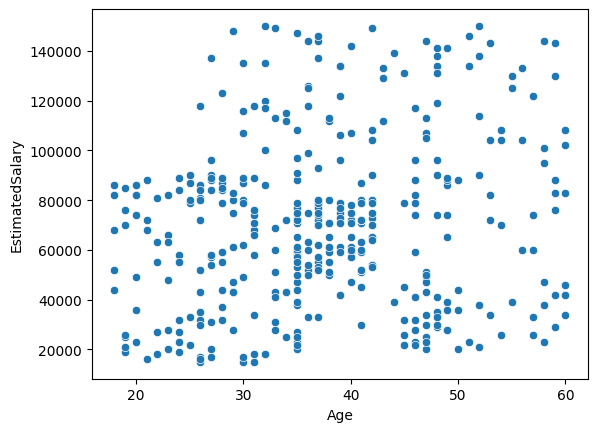

In [45]:
sns.scatterplot(x=df.iloc[:,1], y=df.iloc[:,2])

In [46]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']

# One-hot encode the 'Gender' column
X = pd.get_dummies(X, columns=['Gender'], drop_first=True, dtype=int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [48]:
from tensorflow.keras.models import Sequential

In [49]:
model=Sequential()

In [50]:
model.add(Dense(128,activation='relu',input_dim=3))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [54]:
histroy=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4781 - loss: 56.8552 - val_accuracy: 0.6500 - val_loss: 88.1185
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5406 - loss: 105.4717 - val_accuracy: 0.6500 - val_loss: 105.6232
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4844 - loss: 66.9389 - val_accuracy: 0.6500 - val_loss: 31.6354
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5594 - loss: 123.8358 - val_accuracy: 0.6500 - val_loss: 174.8540
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5219 - loss: 146.7127 - val_accuracy: 0.6500 - val_loss: 150.2444
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5688 - loss: 81.1521 - val_accuracy: 0.3500 - val_loss: 126.2500
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4969 - loss: 78.9863 - val_accuracy: 0.6500 - val_loss: 38.2168
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5094 - loss: 38.876

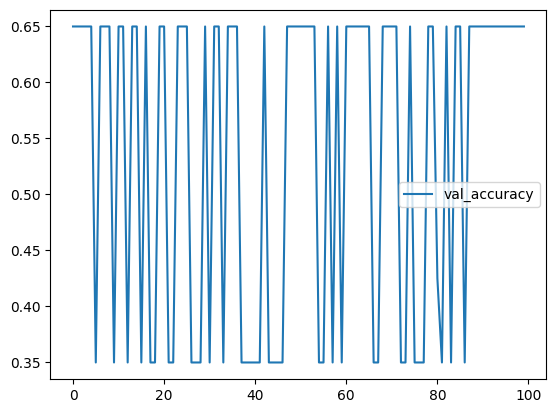

In [56]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

Applying Scaling to reduce this normalization issue

In [57]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [58]:
model=Sequential()
model.add(Dense(128,activation='relu',input_dim=3))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [62]:
histroy=model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9156 - loss: 0.1946 - val_accuracy: 0.9125 - val_loss: 0.2256
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9156 - loss: 0.1934 - val_accuracy: 0.9125 - val_loss: 0.2239
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9187 - loss: 0.1926 - val_accuracy: 0.9250 - val_loss: 0.2181
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9187 - loss: 0.1944 - val_accuracy: 0.9125 - val_loss: 0.2217
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9156 - loss: 0.1915 - val_accuracy: 0.9125 - val_loss: 0.2166
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9187 - loss: 0.1912 - val_accuracy: 0.9125 - val_loss: 0.2191
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9187 - loss: 0.1921 - val_accuracy: 0.9125 - val_loss: 0.2221
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9156 - loss: 0.1924 - val_accuracy: 0.9125 -

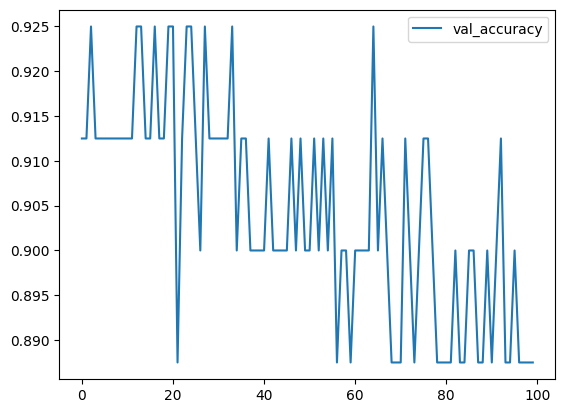

In [64]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

In [71]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_pred=model.predict(X_test_scaled)
y_pred=(y_pred>0.5)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [72]:
print("the accuracy of model is :",accuracy_score(y_test,y_pred))

the accuracy of model is : 0.8875


In [73]:
confusion_matrix(y_test,y_pred)

array([[47,  5],
       [ 4, 24]])